# COMP9444 Group Project - SQL Prompt Generation from Natural-Language Queries

**Project 077 | Natural Language Processing and SQL Query Generation**

This single notebook integrates the complete group workflow: problem definition,
dataset exploration and cleaning, deterministic splitting, baseline and improved
methods, experimental setup, results, error analysis, discussion, reproducibility,
and individual contributions.

## Main finding

On the fixed 940-example test split, the ten-epoch T5-small baseline achieved
**103/940 (10.96%) Normalised Exact Match**. The final V3 FLAN-T5-base system with
schema-aware input, Beam 8 decoding and schema-aware reranking achieved
**166/940 (17.66%)**, an absolute gain of **6.70 percentage points**. SQLGlot
syntax-only validity increased from **88.19% to 90.32%**.

> **Reproducibility design.** The default path is fast and offline: it loads the
> committed logs and 940-row prediction artifacts, then independently recomputes all
> final tables and figures. Data download, token-length analysis, full training and
> checkpoint replay are optional because they require internet, a GPU, external model
> weights and substantially more time.

## 0. Execution controls and environment

The submitted notebook should complete with **Restart Kernel -> Run All** using the
default settings. Change an optional flag only when the corresponding dependencies,
internet connection and GPU/checkpoints are available.

In [1]:
EMBEDDED_ARTIFACTS = {'results/baseline_config.json': 'H4sIAO7wc2oC/02PQQqDMBBF9wXvIFkrqJhKe5kwJoMGkihmlFLx7jWJpV3+9+D/mT275Tmzk0IjHFhkz5wRL70FY1gRpUFYnHaDWICC51hWPKkeSI7C63fgbWI4T3L0Z66rBDyiCrpJUeGmZdyRq4Jrw8JLaDevJAy6gcYwUzc/R7AM+Ccbfr/KZ6MpXhAm98BOSgtod+aO111xsQ2MVkB6CuLRVl9O6CmRAI5U61YregQb/8huxwffwXgTJwEAAA==', 'results/baseline_full_summary.json': 'H4sIAO7wc2oC/22Q3UrEMBBG7xf2HUKvFHRJ+me74LOEdDKugSRTknRxFd/dpO2CgrfzHb4zM1/HA2OVI422OrMqdc/RKWvZpCJa47F6WoEUlPHGX2QhCwjkk/ELLZEJznAmeI/sLZBjc8CVRs3ubXvJRsmw+Nwg+DbMGoSEWq7pr2DCmORVWaNVMuSlpRhzzE91w/t6HJpaNCNvebfhLlsNlNU8hSw1n6XzQ0GSTqXcvGFAIWTf6mn22yipcvzY7mYFsAQFt9Um+Ni9tG0/8KETvG/Gv4ycMQD6rfD0L6oRSOffld0uAVHf2INfnJxQufgqHqv7I1BnpK2Ph+8f9smD7JYBAAA=', 'results/baseline_predictions.csv': '...', 'results/baseline_training_log.csv': 'H4sIAO7wc2oC/x1QXUqEQQx7H5ibfCz9b3MaWURQWFxR8fy28zBDCWnS5O3r+fp+/X7fPz5fHs+fn+vv/jjDXnzxjYIAsSTr5yoX3ZwCzCghD5jYXgfNNCrNVJCkR0MKBrs6mqlVe2mDFgovJU5HFuXwTIXawAEYyGIvGyZRaIlwf8GQ2VYmKmhZzQUo3csH9qQkibYqFcGo9sSZWUyeViN6bhLXdOEWjIiM2ZYoS1ZzKTjI9zr76PM7e4xI8SG2EpLZOJzaZ68aNKHQLE/0umMgc7NSIDqN+kgeOMS7Q2tdb/aElHO6IaAEM86unY5CpXWVzk4dH8deKaQzdyPdUre/1z9N+TJHvgEAAA==', 'results/member3/v3_full_run/improved_training_log.csv': 'H4sIAO7wc2oC/12R60oDUQyE/wu+yaHkMrk9jSyloFCt1EV8fHN2i1X/7eZkvpkkp/fL8Xms1+Xl7el8+fgYn8v5/nH6Wo7r0+uyds/9/3i5Xk/H9VdlvazL+fGBBw5ZzkJARZSKDT6YmDEnG5eksQ06EAlLuJUF4ElpQ0aBHh+kBd1FbE4UoQn1FnhBypxhXTPIZMhfCA+unaH9GgL29DQXZEfpUmstXKqzeYVsOW7uTK4p1W245cAUVCCMXKLMKGcOhYl3UQmllrOLqudTLkaWOsfI2BHTQDvaXAUxGF4yBZKR7qai7g61yWWOv9MMZtoxmy1ZSU9EYT1STIiTCDGxtCXVxtDN/4fTDOWdsSucMryfWgrhWYKma5+m98xQyUnpk+Emy60HSgnMyEDvaasRt1vjM62n3nX/TtoY3THfWHeJg2QCAAA=', 'results/member3/v3_full_run/beam_search_comparison.json': 'H4sIAO7wc2oC/22R0WrDMAxF3wf9B5HnUZIl7drtG/a0DzCKoqWG2Aqy0y4b+/e5aejasBdjdM4VF/S9egDIHEe1lL1A5kUddvaLG8OfSNE4jHTIHieNxPWoNog/q4EO7NDgCZVNq8zNaI7B3I1rRmd2c7xHq2lvnx5L0YoPac2+yi+0xsCd9Ww+bMdG5XRHretVjin9L71mSVSZYmJFWS6SN2y7XeRCgpxIvi6qotrtF9Eb/Lzd7Oc01kG6IbKZPcc+TlJebop8lnpWSnNs2fRifVzI5fpPvbYR3403dZdtFrh6unAv8dwxe0+39C1M54PpfGADNBZbLyFaek2IaTgfAJBoUKQRwkGGroGaAZuG02eEN3Y1K1TrbPXw8wtQL5GhKAIAAA==', 'results/member3/v3_full_run/improved_predictions.csv': '...', 'results/member3/v3_full_run/sqlglot_validity_comparison.json': 'H4sIAO7wc2oC/5WTTY+bMBCG75X6H0Y5Z1m+Qszeeuqll6q9I6+ZJNYam7UNLVrtf68NSUi0IfVKCPD4nQ8/nnn7+gVg1aDVnK2eYGVexV4oW/VU8JrbodLU4mo9qmrcccktV9Irv0GrsebMr4EbGD3gzwHdynqDVPIBm9YOa/j188d3FxVaqg0av08N4F/KrBhASfQCbhFeO9ROTmUN9oBgVfsgsEfhtC6ZMcdUdBJG8NuJptqhVuhTWmAHZC9g3KehIGnjzEq7AMg6OyaKTsfhVCCzx1Pz8zHNYCw2xtnf/HrE0zyjTqtnalBwidVeI9bDrHCaHRfoQ7kyO2HN41k7UzIRM/2UZHQZiTkfkpazkcuTOUmS2WyVpcIZyzyejePdPEEcEZKUSU7KrEi2cZqks6RFzVBauvdCQqIlHXOh9koPFVOdtObyaAuV+uD+OivUWump3tPe+/Tzvr4CmFW9Y4i0qTRqKl+wvkvw6PTIm1arHusgkultkiSY5DbPCxKTTRIXGcmWQG6jS9nl/YWCTO+BJP8FmYX04ImgU+86ISrdyZnm5B8CNStuQo3z8PY8d9y22JSb5fa80hWfpnpR6UeqcR5A9fPteRNuANX85tCXwTNfxtnVMC9ALeNoSRcINb8z8+WHkfcf93LPP0lak5FbBgAA'}

from pathlib import Path
import csv
import hashlib
import json
import os
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

RUN_DATA_DOWNLOAD = False
RUN_TOKEN_LENGTH_ANALYSIS = False
RUN_FULL_TRAINING = False
RUN_CHECKPOINT_REPLAY = False

def find_project_root(start=None):
    # Find the repository when launched from its root, notebooks/, or a sibling path.
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    candidates += [
        parent / "SQL-Prompt-Generation-from-Natural-Language-Queries"
        for parent in [start, *start.parents]
    ]
    for candidate in candidates:
        if (candidate / "results/baseline_predictions.csv").is_file() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    import base64
    import gzip
    import tempfile

    _embedded_root = Path(tempfile.mkdtemp(prefix="comp9444_embedded_"))
    for relative_path, encoded in EMBEDDED_ARTIFACTS.items():
        destination = _embedded_root / relative_path
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_bytes(gzip.decompress(base64.b64decode(encoded)))
    PROJECT_ROOT = Path.cwd().resolve()
    RESULTS_DIR = _embedded_root / "results"
    ARTIFACT_MODE = "standalone embedded artifacts"
else:
    RESULTS_DIR = PROJECT_ROOT / "results"
    ARTIFACT_MODE = "repository artifacts"
SEED = 42
SPLIT_SIZES = {"train": 7517, "validation": 940, "test": 940}

print("Artifact mode:", ARTIFACT_MODE)
print("Python:", sys.version.split()[0])
print("Optional flags:", {
    "data_download": RUN_DATA_DOWNLOAD,
    "token_analysis": RUN_TOKEN_LENGTH_ANALYSIS,
    "full_training": RUN_FULL_TRAINING,
    "checkpoint_replay": RUN_CHECKPOINT_REPLAY,
})

Artifact mode: repository artifacts
Python: 3.13.5
Optional flags: {'data_download': False, 'token_analysis': False, 'full_training': False, 'checkpoint_replay': False}


## 1. Introduction, motivation and problem statement

Relational databases store large amounts of structured information, but retrieving it
normally requires knowledge of SQL. Text-to-SQL generation removes this barrier by
mapping a natural-language question and database schema to a query. This is difficult
because the model must identify relevant tables and columns, follow relationships,
and compose joins, filters, aggregations, ordering and nested queries while preserving
syntax and intent.

The project uses the **AI4DS/SQL Generator No CoT** dataset to investigate whether a
sequence-to-sequence baseline can be improved through clearer schema context, greater
model capacity and multi-candidate decoding. The central research question is:

> **Can schema-aware formatting and decoding improve SQL generation over a T5-small
> greedy baseline on a fixed held-out test set?**

## 2. Data source and preprocessing

The public dataset contains English prompt-response pairs. A prompt includes task
instructions, a database schema, the natural-language question and sometimes a hint;
the response contains the target SQL inside a Markdown code block. The source is:

`https://huggingface.co/datasets/AI4DS/sql_generator_no_cot`

The cleaning pipeline removes exact duplicate rows, strips surrounding whitespace and
extracts pure SQL from the response code block. Cleaning occurs **before** the
deterministic 80/10/10 split to reduce leakage from duplicate rows.

In [2]:
DATASET_URL = "hf://datasets/AI4DS/sql_generator_no_cot/training_no_cot_dataset.csv"

def clean_dataset(dataframe):
    cleaned = dataframe[["prompt", "response"]].copy()
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    cleaned["prompt"] = cleaned["prompt"].astype(str).str.strip()
    cleaned["sql"] = (
        cleaned["response"].astype(str)
        .str.replace("```sql", "", regex=False)
        .str.replace("```", "", regex=False)
        .str.strip()
    )
    return cleaned[["prompt", "sql"]]

if RUN_DATA_DOWNLOAD:
    raw_df = pd.read_csv(DATASET_URL)
    clean_df = clean_dataset(raw_df)
    print("Downloaded rows:", len(raw_df))
    print("Cleaned rows:", len(clean_df))
else:
    raw_df = clean_df = None
    print("Download skipped; using the verified EDA snapshot below.")

Download skipped; using the verified EDA snapshot below.


## 3. Exploratory data analysis

The following snapshot was generated by the group's executed data-cleaning notebook.
It remains visible and reproducible offline; setting `RUN_DATA_DOWNLOAD=True`
recomputes the underlying dataframe from the public source.

In [3]:
eda_snapshot = {
    "raw_rows": 9399,
    "raw_columns": 2,
    "missing_prompt": 0,
    "missing_response": 0,
    "empty_prompt": 0,
    "empty_response": 0,
    "duplicate_copies": 2,
    "clean_rows": 9397,
    "all_select_queries": 9397,
}

if raw_df is not None:
    observed = {
        "raw_rows": len(raw_df),
        "raw_columns": len(raw_df.columns),
        "missing_prompt": int(raw_df["prompt"].isna().sum()),
        "missing_response": int(raw_df["response"].isna().sum()),
        "empty_prompt": int((raw_df["prompt"].astype(str).str.strip() == "").sum()),
        "empty_response": int((raw_df["response"].astype(str).str.strip() == "").sum()),
        "duplicate_copies": int(raw_df.duplicated().sum()),
        "clean_rows": len(clean_df),
        "all_select_queries": int(clean_df["sql"].str.upper().str.startswith("SELECT").sum()),
    }
    assert observed == eda_snapshot, (observed, eda_snapshot)

display(pd.DataFrame({"Statistic": eda_snapshot.keys(), "Value": eda_snapshot.values()}))

,Statistic,Value
0,raw_rows,9399
1,raw_columns,2
2,missing_prompt,0
3,missing_response,0
4,empty_prompt,0
5,empty_response,0
6,duplicate_copies,2
7,clean_rows,9397
8,all_select_queries,9397


In [4]:
length_summary = pd.DataFrame(
    {
        "Prompt characters": [9399, 1437.28, 724, 1397, 4758],
        "Response characters": [9399, 183.49, 36, 175, 817],
        "Prompt tokens (T5)": [9397, 371.64, 157, 359, 1313],
        "SQL tokens (T5)": [9397, 75.30, 10, 71, 391],
    },
    index=["count", "mean", "min", "median", "max"],
)
display(length_summary.round(2))

truncation_snapshot = pd.DataFrame({
    "maximum input tokens": [512, 1024, 1536, 2048],
    "prompts truncated": [690, 4, 0, 0],
    "percentage": [7.34, 0.04, 0.00, 0.00],
})
display(truncation_snapshot)

,Prompt characters,Response characters,Prompt tokens (T5),SQL tokens (T5)
count,9399.00,9399.00,9397.00,9397.0
mean,1437.28,183.49,371.64,75.3
min,724.00,36.00,157.00,10.0
median,1397.00,175.00,359.00,71.0
max,4758.00,817.00,1313.00,391.0


,maximum input tokens,prompts truncated,percentage
0,512,690,7.34
1,1024,4,0.04
2,1536,0,0.00
3,2048,0,0.00


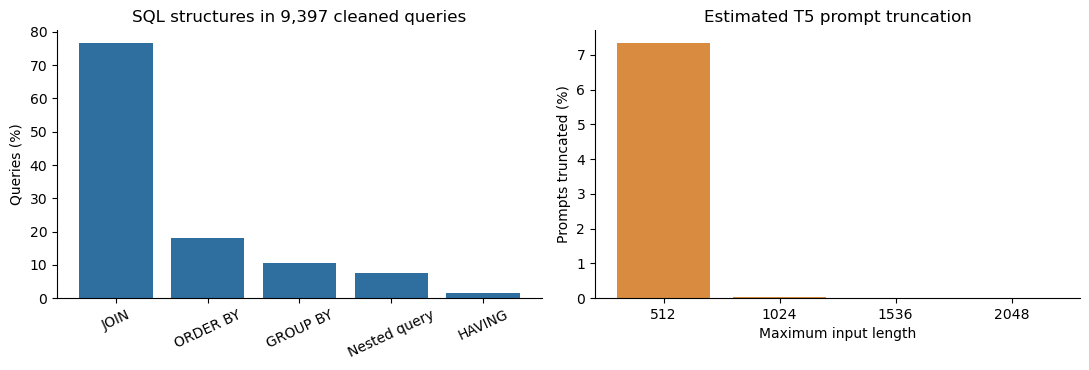

In [5]:
complexity = pd.DataFrame(
    {
        "Structure": ["JOIN", "ORDER BY", "GROUP BY", "Nested query", "HAVING"],
        "Count": [7202, 1701, 1004, 721, 141],
        "Percentage": [76.64, 18.10, 10.68, 7.67, 1.50],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(complexity["Structure"], complexity["Percentage"], color="#2f6f9f")
axes[0].set_title("SQL structures in 9,397 cleaned queries")
axes[0].set_ylabel("Queries (%)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].bar(truncation_snapshot["maximum input tokens"].astype(str),
            truncation_snapshot["percentage"], color="#d98c3f")
axes[1].set_title("Estimated T5 prompt truncation")
axes[1].set_ylabel("Prompts truncated (%)")
axes[1].set_xlabel("Maximum input length")
axes[1].spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### EDA interpretation

- The source contains **9,399** rows and no missing/empty prompt or response values.
- Removing two duplicate copies leaves **9,397** unique examples.
- Every cleaned target begins with `SELECT`; the task concerns retrieval rather than
  database modification.
- **76.64%** of targets contain a join, confirming that schema relationships are a
  central challenge. Grouping, ordering, conditional aggregation and nested queries
  add further compositional difficulty.
- With a 512-token limit, **690 prompts (7.34%)** can be truncated. This motivates the
  improved question-first, compact-schema representation.

In [6]:
def deterministic_split(dataframe, seed=42):
    # Reproduce the 80/10/10 split used by the project.
    from sklearn.model_selection import train_test_split
    train, temporary = train_test_split(
        dataframe, test_size=0.20, random_state=seed, shuffle=True
    )
    validation, test = train_test_split(
        temporary, test_size=0.50, random_state=seed, shuffle=True
    )
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

if clean_df is not None:
    train_df, validation_df, test_df = deterministic_split(clean_df, SEED)
    assert [len(train_df), len(validation_df), len(test_df)] == [7517, 940, 940]

display(pd.DataFrame({"Split": SPLIT_SIZES.keys(), "Rows": SPLIT_SIZES.values()}))

,Split,Rows
0,train,7517
1,validation,940
2,test,940


## 4. Models and methods

### 4.1 T5-small baseline — Member 2

T5 frames every task as text-to-text generation, making it a suitable and transparent
baseline. The model receives the full cleaned prompt and generates SQL. It was trained
for ten epochs using AdamW, learning rate $5\times10^{-5}$, batch size 4, maximum
input/target lengths 512/256, seed 42 and greedy decoding (`num_beams=1`). The best
checkpoint was selected using validation loss.

,Parameter,Value
0,Model,t5-small
1,Epochs,10
2,Learning rate,5e-5
3,Batch size,4
4,Input / target limit,512 / 256
5,Seed,42
6,Decoding,Greedy (1 beam)


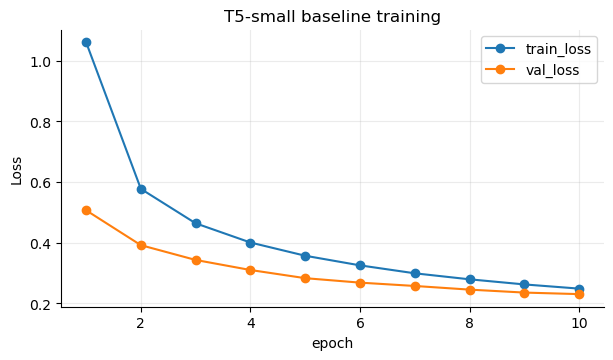

In [7]:
baseline_config = json.loads((RESULTS_DIR / "baseline_config.json").read_text(encoding="utf-8"))
baseline_summary = json.loads((RESULTS_DIR / "baseline_full_summary.json").read_text(encoding="utf-8"))
baseline_log = pd.read_csv(RESULTS_DIR / "baseline_training_log.csv")

display(pd.DataFrame({
    "Parameter": ["Model", "Epochs", "Learning rate", "Batch size", "Input / target limit", "Seed", "Decoding"],
    "Value": ["t5-small", 10, "5e-5", 4, "512 / 256", 42, "Greedy (1 beam)"],
}))

ax = baseline_log.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", figsize=(7, 3.6))
ax.set_title("T5-small baseline training")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [8]:
# Complete training is intentionally opt-in. The implementation lives in src/baseline.py.
baseline_training_command = [
    sys.executable, "-m", "src.main", "baseline",
    "--epochs", "10", "--batch_size", "4", "--learning_rate", "5e-5",
    "--seed", "42", "--max_prediction_batches", "235",
]

print("Baseline training command: python -m src.main baseline --epochs 10 --batch_size 4 --learning_rate 5e-5 --seed 42 --max_prediction_batches 235")
if RUN_FULL_TRAINING:
    subprocess.run(baseline_training_command, cwd=PROJECT_ROOT, check=True)
else:
    print("Training skipped; committed ten-epoch log and predictions are used.")

Baseline training command: python -m src.main baseline --epochs 10 --batch_size 4 --learning_rate 5e-5 --seed 42 --max_prediction_batches 235
Training skipped; committed ten-epoch log and predictions are used.


### 4.2 V3 schema-aware FLAN-T5-base - Member 3

The final system addresses two observed weaknesses:

1. **Long generic inputs:** the natural-language question is placed before a compact
   schema so truncation is less likely to remove the request.
2. **Unconstrained generation:** eight beam candidates are generated and reranked by
   model score plus schema consistency, discouraging nonexistent identifiers and
   broken aliases.

The model is FLAN-T5-base, trained for eight epochs with learning rate $10^{-4}$,
batch size 2, gradient accumulation 2, weight decay 0.01 and seed 42. The final
decoder uses Beam 8, length penalty 0.9, repetition penalty 1.08 and schema reranking
weight 0.75. This is a combined system improvement rather than a component-wise
ablation.

In [9]:
def extract_prompt_sections(prompt):
    # Extract schema, question and optional hint from the public prompt template.
    prompt = str(prompt).replace("\r\n", "\n")
    schema_match = re.search(r"(?im)^\s*Database\s+Schema\s*$", prompt)
    question_match = re.search(r"(?im)^\s*Question\s*:\s*$", prompt)
    hint_match = re.search(r"(?im)^\s*Hint\s*:\s*$", prompt)
    if not schema_match or not question_match:
        return {}
    question_end = hint_match.start() if hint_match else len(prompt)
    return {
        "schema": re.sub(r"\s+", " ", prompt[schema_match.end():question_match.start()]).strip(" #\n"),
        "question": re.sub(r"\s+", " ", prompt[question_match.end():question_end]).strip(),
        "hint": re.sub(r"\s+", " ", prompt[hint_match.end():]).strip() if hint_match else "",
    }

def build_question_first_input(prompt):
    sections = extract_prompt_sections(prompt)
    if not sections:
        return "translate natural language to SQLite:\n" + re.sub(r"\s+", " ", str(prompt)).strip()
    parts = [
        "translate to SQLite. Use only listed identifiers. Return only SQL:",
        "question: " + sections["question"],
    ]
    if sections["hint"]:
        parts.append("hint: " + sections["hint"])
    parts.append("schema: " + sections["schema"])
    return "\n".join(parts)

demonstration_prompt = (
    "Database Schema\nCREATE TABLE sales(id INTEGER, qty INTEGER, price REAL);\n"
    "Question:\nWhich sale has the highest quantity?\n"
    "Hint:\nUse ORDER BY and LIMIT."
)
print(build_question_first_input(demonstration_prompt))

translate to SQLite. Use only listed identifiers. Return only SQL:
question: Which sale has the highest quantity?
hint: Use ORDER BY and LIMIT.
schema: CREATE TABLE sales(id INTEGER, qty INTEGER, price REAL);


,Parameter,Value
0,Model,google/flan-t5-base
1,Epochs,8
2,Learning rate,1e-4
3,Batch / accumulation,2 / 2
4,Beam,8
5,Length penalty,0.9
6,Repetition penalty,1.08
7,Rerank weight,0.75


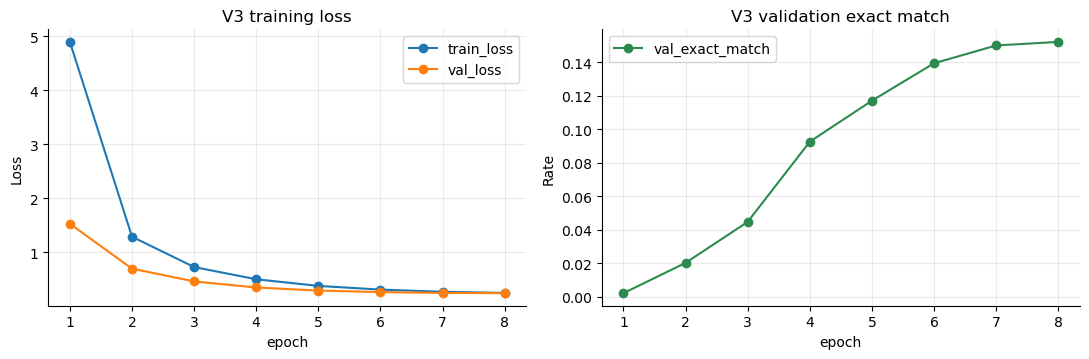

Greedy V3: 133 / 940
Beam 8 + reranking: 166 / 940


In [10]:
improved_log = pd.read_csv(RESULTS_DIR / "member3/v3_full_run/improved_training_log.csv")
beam_comparison = json.loads(
    (RESULTS_DIR / "member3/v3_full_run/beam_search_comparison.json").read_text(encoding="utf-8")
)

display(pd.DataFrame({
    "Parameter": ["Model", "Epochs", "Learning rate", "Batch / accumulation", "Beam", "Length penalty", "Repetition penalty", "Rerank weight"],
    "Value": ["google/flan-t5-base", 8, "1e-4", "2 / 2", 8, 0.9, 1.08, 0.75],
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
improved_log.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", ax=axes[0])
axes[0].set_title("V3 training loss")
axes[0].set_ylabel("Loss")
improved_log.plot(x="epoch", y="val_exact_match", marker="o", color="#2d8a4e", ax=axes[1])
axes[1].set_title("V3 validation exact match")
axes[1].set_ylabel("Rate")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("Greedy V3:", beam_comparison["baseline_correct"], "/ 940")
print("Beam 8 + reranking:", beam_comparison["improved_correct"], "/ 940")

In [11]:
# Complete improved-model training is opt-in and implemented in src/improvement.py.
improved_training_command = [
    sys.executable, "-m", "src.main", "improvement",
    "--model_name", "google/flan-t5-base", "--epochs", "8",
    "--batch_size", "2", "--learning_rate", "1e-4", "--seed", "42",
    "--num_beams", "8", "--schema_rerank_weight", "0.75",
]

print("Improved training command: python -m src.main improvement --model_name google/flan-t5-base --epochs 8 --batch_size 2 --learning_rate 1e-4 --seed 42 --num_beams 8 --schema_rerank_weight 0.75")
if RUN_FULL_TRAINING:
    subprocess.run(improved_training_command, cwd=PROJECT_ROOT, check=True)
else:
    print("Training skipped; committed V3 log and predictions are used.")

Improved training command: python -m src.main improvement --model_name google/flan-t5-base --epochs 8 --batch_size 2 --learning_rate 1e-4 --seed 42 --num_beams 8 --schema_rerank_weight 0.75
Training skipped; committed V3 log and predictions are used.


## 5. Experimental setup and evaluation - Member 4

Both systems use the same deterministic split (7,517 train, 940 validation and 940
test examples) and seed 42. Final comparison uses the frozen prediction artifact for
each system's actual decoding configuration.

**Normalised Exact Match (EM)** lowercases and trims SQL, collapses whitespace,
standardises punctuation/operator spacing and removes one trailing semicolon. It is a
strict string-level diagnostic; equivalent SQL can still fail to match.

**SQLGlot syntax-only validity** checks whether a non-empty prediction parses as one
SQLite query expression. It does not validate schema names or execute SQL.

In [12]:
BASELINE_PATH = RESULTS_DIR / "baseline_predictions.csv"
IMPROVED_PATH = RESULTS_DIR / "member3/v3_full_run/improved_predictions.csv"
VALIDITY_PATH = RESULTS_DIR / "member3/v3_full_run/sqlglot_validity_comparison.json"

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_predictions(path):
    with path.open(encoding="utf-8", newline="") as stream:
        rows = list(csv.DictReader(stream))
    assert rows and {"target_sql", "predicted_sql"}.issubset(rows[0])
    return rows

baseline_rows = load_predictions(BASELINE_PATH)
improved_rows = load_predictions(IMPROVED_PATH)
assert len(baseline_rows) == len(improved_rows) == 940

# Formatting changed between pipeline stages, but removing whitespace confirms that
# all 940 target SQL strings are aligned in the same row order.
alignment = sum(
    re.sub(r"\s+", "", left["target_sql"]).rstrip(";").lower()
    == re.sub(r"\s+", "", right["target_sql"]).rstrip(";").lower()
    for left, right in zip(baseline_rows, improved_rows)
)
assert alignment == 940

print("Rows per artifact:", len(baseline_rows))
print("Whitespace-insensitive target alignment:", alignment, "/ 940")
print("Baseline SHA-256:", file_sha256(BASELINE_PATH))
print("Improved SHA-256:", file_sha256(IMPROVED_PATH))

Rows per artifact: 940
Whitespace-insensitive target alignment: 940 / 940
Baseline SHA-256: 148022a082f249b4049983cb0a83502ad0a42d5add88ac2d4af764aa66d2a37f
Improved SHA-256: aafd7c08d34b14a21939fe8af4df58bcc2a45766ba87c09f8b37de623423a554


In [13]:
def normalize_sql(sql):
    text = re.sub(r"\s+", " ", str(sql).strip().lower())
    text = re.sub(r"\s*([(),=<>])\s*", r"\1", text)
    return text[:-1].rstrip() if text.endswith(";") else text

def score_predictions(rows):
    flags = [normalize_sql(row["target_sql"]) == normalize_sql(row["predicted_sql"]) for row in rows]
    return sum(flags), len(flags), flags

baseline_correct, total, baseline_flags = score_predictions(baseline_rows)
improved_correct, _, improved_flags = score_predictions(improved_rows)
assert (baseline_correct, improved_correct, total) == (103, 166, 940)

validity = json.loads(VALIDITY_PATH.read_text(encoding="utf-8"))["systems"]
baseline_valid = validity["member2_baseline_greedy"]["valid"]
improved_valid = validity["member3_v3_beam_reranked"]["valid"]
assert (baseline_valid, improved_valid) == (829, 849)

final_results = pd.DataFrame([
    ["T5-small baseline (greedy)", 103, 10.96, 829, 88.19],
    ["V3 FLAN-T5-base (Beam 8 + reranking)", 166, 17.66, 849, 90.32],
], columns=["System", "Exact matches", "Normalised EM (%)", "Valid SQL", "SQLGlot validity (%)"])
display(final_results)
print("Absolute EM improvement: 63 queries / 6.70 percentage points")

,System,Exact matches,Normalised EM (%),Valid SQL,SQLGlot validity (%)
0,T5-small baseline (greedy),103,10.96,829,88.19
1,V3 FLAN-T5-base (Beam 8 + reranking),166,17.66,849,90.32


Absolute EM improvement: 63 queries / 6.70 percentage points


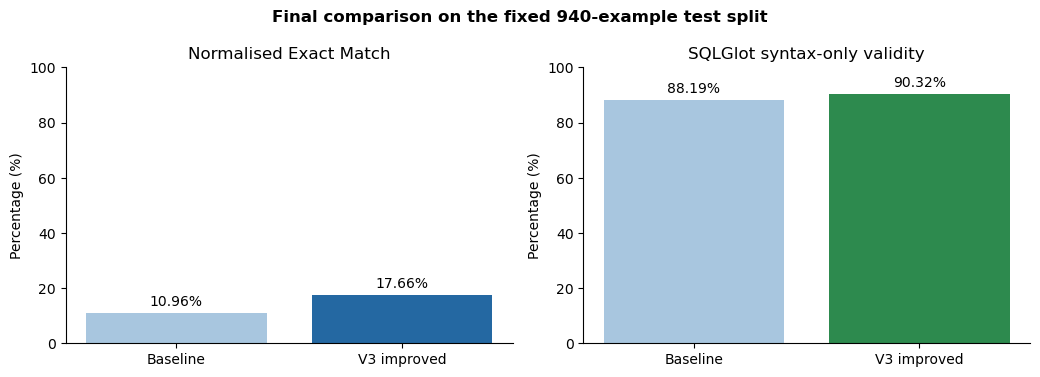

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, values, title, color in zip(
    axes,
    [[10.96, 17.66], [88.19, 90.32]],
    ["Normalised Exact Match", "SQLGlot syntax-only validity"],
    ["#2468a2", "#2d8a4e"],
):
    bars = ax.bar(["Baseline", "V3 improved"], values, color=["#a8c6df", color])
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(title)
    ax.bar_label(bars, fmt="%.2f%%", padding=3)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Final comparison on the fixed 940-example test split", fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Paired comparison and error analysis

Row-level pairing distinguishes improvements from regressions. The final V3 system
corrects 94 examples missed by the baseline, while the baseline alone is correct on
31 examples. Both systems are correct on 72 and incorrect on 743.

,Examples
Both correct,72
Improved only,94
Baseline only,31
Neither correct,743


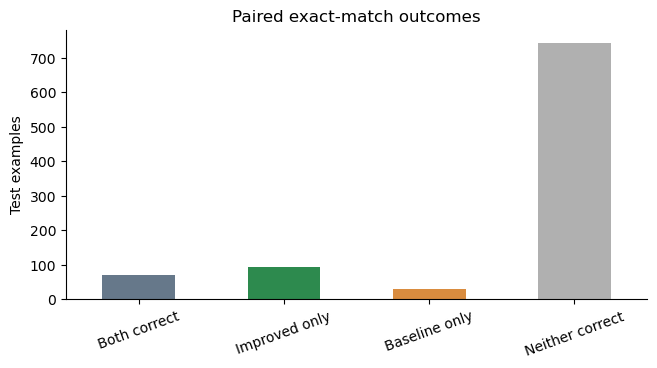

In [15]:
paired = pd.Series({
    "Both correct": sum(b and i for b, i in zip(baseline_flags, improved_flags)),
    "Improved only": sum((not b) and i for b, i in zip(baseline_flags, improved_flags)),
    "Baseline only": sum(b and (not i) for b, i in zip(baseline_flags, improved_flags)),
    "Neither correct": sum((not b) and (not i) for b, i in zip(baseline_flags, improved_flags)),
})
assert paired.to_dict() == {"Both correct": 72, "Improved only": 94, "Baseline only": 31, "Neither correct": 743}
display(paired.to_frame("Examples"))

ax = paired.plot.bar(color=["#66788a", "#2d8a4e", "#d98c3f", "#b0b0b0"], figsize=(7.5, 3.5))
ax.set_title("Paired exact-match outcomes")
ax.set_ylabel("Test examples")
ax.tick_params(axis="x", rotation=20)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [16]:
examples = []
for index, (base, improved, base_ok, improved_ok) in enumerate(
    zip(baseline_rows, improved_rows, baseline_flags, improved_flags)
):
    if improved_ok and not base_ok:
        examples.append({
            "Row": index,
            "Target": improved["target_sql"],
            "Baseline prediction": base["predicted_sql"],
            "V3 prediction": improved["predicted_sql"],
        })
    if len(examples) == 3:
        break
display(pd.DataFrame(examples))

,Row,Target,Baseline prediction,V3 prediction
0,20,SELECT T2.ps_supplycost FROM part AS T1 INNER ...,SELECT T2.ps_supplycost FROM partsupp AS T1 IN...,SELECT T2.ps_supplycost FROM part AS T1 INNER ...
1,34,SELECT T1.name FROM unemployed AS T1 INNER JOI...,SELECT T2.name FROM enlist AS T1 INNER JOIN un...,SELECT T1.name FROM unemployed AS T1 INNER JOI...
2,44,SELECT T3.Name FROM movie AS T1 INNER JOIN cha...,SELECT T3.Name FROM movie AS T1 INNER JOIN cha...,SELECT T3.Name FROM movie AS T1 INNER JOIN cha...


### Error interpretation

Inspection of generated queries identifies recurring failures:

1. **Schema linking:** selecting a wrong or nonexistent table/column.
2. **Join composition:** missing or incorrect join keys and aliases.
3. **Query intent:** changing filters, aggregation, grouping, ordering or limits.
4. **Complex structure:** incomplete nested queries or multi-step logic.
5. **Surface-form mismatch:** aliases or equivalent query formulations differ from the
   reference despite potentially expressing similar semantics.

Syntax validity is much higher than exact match because a parseable query can still
express the wrong intent. Conversely, exact match can reject a semantically equivalent
query. This motivates execution-based evaluation when databases are available.

## 7. Integration and reproducibility - Member 5

The group modules are exposed through one command-line entry point:

```bash
python -m src.main doctor
python -m src.main demo
python -m src.main test
python -m src.main baseline --help
python -m src.main improvement --help
python -m src.main evaluate --help
```

The offline demo verifies committed prediction artifacts and final metrics. Full
checkpoint inference is separate: the baseline uses greedy decoding, whereas final V3
requires Beam 8 and schema-aware reranking. Replaying both checkpoints with one shared
greedy configuration is a diagnostic smoke test, not the final experiment.

In [17]:
print(f"{'System':<43}{'Correct':>10}{'Total':>8}{'Normalised EM':>18}")
print("-" * 79)
print(f"{'T5-small baseline':<43}{baseline_correct:>10}{total:>8}{baseline_correct/total:>17.2%}")
print(f"{'V3 FLAN-T5-base, Beam 8 + reranking':<43}{improved_correct:>10}{total:>8}{improved_correct/total:>17.2%}")

if RUN_CHECKPOINT_REPLAY:
    print("Checkpoint replay requires external model folders and their original decoding settings.")
else:
    print("Checkpoint replay skipped; artifact verification completed successfully.")

System                                        Correct   Total     Normalised EM
-------------------------------------------------------------------------------
T5-small baseline                                 103     940           10.96%
V3 FLAN-T5-base, Beam 8 + reranking               166     940           17.66%
Checkpoint replay skipped; artifact verification completed successfully.


## 8. Discussion, strengths and limitations

### Strengths

- The comparison uses a fixed seed, deterministic split and aligned 940-example test
  artifacts.
- V3 produces 63 additional exact matches and 20 additional syntactically valid
  queries.
- EDA provides a direct rationale for the question-first schema representation:
  76.64% of targets use joins and 7.34% of prompts exceed 512 T5 tokens.
- Frozen prediction files, hashes and a unified entry point support repeatable result
  verification without expensive retraining.

### Limitations

- **Execution accuracy is not reported.** Populated databases and a reliable mapping
  from each example to its database are unavailable. SQLGlot validity is syntax-only.
- The row-level split is not schema-disjoint, so related schemas may occur across
  training and test sets.
- V3 combines model capacity, input ordering, target normalisation, checkpoint
  selection, beam search and reranking. A component-wise ablation is required to
  isolate the contribution of each change.
- Most test predictions still fail strict exact match, showing that schema linking and
  compositional generation remain difficult.

Future work should add execution-based accuracy, schema-disjoint evaluation, paired
significance testing, controlled ablations, stronger schema linking and constrained
decoding.

## 9. Conclusion

This project implemented and evaluated a complete text-to-SQL pipeline. Cleaning left
9,397 unique prompt-SQL pairs and revealed a challenging dataset dominated by joins
and long schema-rich inputs. The T5-small baseline achieved 10.96% Normalised Exact
Match, while the final schema-aware FLAN-T5-base system with Beam 8 and reranking
achieved 17.66%. Syntax-only validity also increased from 88.19% to 90.32%.

The improvement supports clearer schema presentation, increased model capacity and
multi-candidate decoding, but it does not establish semantic correctness. Reliable
execution-based evaluation and schema-disjoint generalisation remain the most
important next steps.

### Contribution map

- **Member 1:** problem framing, data source, cleaning and exploratory analysis.
- **Member 2:** T5-small baseline training, logs, checkpoint and predictions.
- **Member 3:** schema-aware FLAN-T5-base, target processing, Beam 8 and reranking.
- **Member 4:** evaluation protocol, SQLGlot validity and error analysis.
- **Member 5:** code integration, GitHub workflow, unified demo, reproducibility and
  final notebook consistency.

## References

1. AI4DS, **SQL Generator No CoT**, Hugging Face Datasets.  
   https://huggingface.co/datasets/AI4DS/sql_generator_no_cot
2. C. Raffel et al., “Exploring the Limits of Transfer Learning with a Unified
   Text-to-Text Transformer,” *Journal of Machine Learning Research*, 21(140), 1–67,
   2020.
3. H. W. Chung et al., “Scaling Instruction-Finetuned Language Models,” *Journal of
   Machine Learning Research*, 25, 1–53, 2024.
4. B. Wang et al., “RAT-SQL: Relation-Aware Schema Encoding and Linking for
   Text-to-SQL Parsers,” *ACL*, 6778–6792, 2020.
5. V. Zhong, C. Xiong and R. Socher, “Seq2SQL: Generating Structured Queries from
   Natural Language using Reinforcement Learning,” *EMNLP*, 600–607, 2017.
6. X. Xu, C. Liu and D. Song, “SQLNet: Generating Structured Queries from Natural
   Language without Reinforcement Learning,” arXiv:1711.04436, 2017.